 # RetailRocket Stream Mining


 ## 1. Imports and configuration

In [1]:
import os, math
from collections import deque, Counter, defaultdict

import matplotlib.pyplot as plt

from river import (
    stream, forest, tree, imblearn, metrics, anomaly, stats,
)

TABLE2_PATH = '/Users/maciej/Desktop/MLDS_workspace/data_retailrocket/table2_stream.csv'
PLOT_DIR    = '/Users/maciej/Desktop/MLDS_workspace/data_retailrocket/plots_v10'
os.makedirs(PLOT_DIR, exist_ok=True)

GLOBAL_WINDOW       = 2_000
GRAPH_EDGES         = 5_000
LOG_EVERY           = 10_000
HYBRID_THRESHOLD    = 0.1
TOP_K               = 5
MAX_ROWS            = 500_000
SESSION_GAP_SECONDS = 30 * 60
EVENT_WEIGHTS       = {'view': 1.0, 'addtocart': 3.0, 'transaction': 5.0}


 ## 2. Top-K and MRR metrics

In [2]:
class TopKAccuracy:
    def __init__(self, k=5):
        self.k = k
        self.correct = 0
        self.total = 0

    def update(self, y_true, proba_dict):
        if not proba_dict:
            return
        topk = sorted(proba_dict.items(), key=lambda kv: kv[1], reverse=True)[:self.k]
        if any(cls == y_true for cls, _ in topk):
            self.correct += 1
        self.total += 1

    def get(self):
        return self.correct / self.total if self.total else 0.0


class MRR:
    def __init__(self):
        self.sum_rr = 0.0
        self.total = 0

    def update(self, y_true, proba_dict):
        if not proba_dict:
            return
        ranked = sorted(proba_dict.items(), key=lambda kv: kv[1], reverse=True)
        for rank, (cls, _) in enumerate(ranked, start=1):
            if cls == y_true:
                self.sum_rr += 1.0 / rank
                break
        self.total += 1

    def get(self):
        return self.sum_rr / self.total if self.total else 0.0


 ## 3. Cold-start strategies (unchanged from v9)

In [3]:
class GlobalTrendingColdStart:
    def __init__(self, window_size=GLOBAL_WINDOW):
        self.history = deque(maxlen=window_size)
        self.counts = Counter()

    def predict(self):
        if not self.counts:
            return None, 0.0
        top, count = self.counts.most_common(1)[0]
        total = sum(self.counts.values())
        return top, count / total

    def proba_dict(self):
        if not self.counts:
            return {}
        total = sum(self.counts.values())
        return {cat: c / total for cat, c in self.counts.items()}

    def update(self, category):
        if category is None:
            return
        if len(self.history) == self.history.maxlen:
            old = self.history[0]
            self.counts[old] -= 1
            if self.counts[old] == 0:
                del self.counts[old]
        self.history.append(category)
        self.counts[category] += 1


class IntentColdStart:
    def __init__(self):
        self.n_total = 0
        self.n_transactions = 0

    def base_rate(self):
        if self.n_total == 0:
            return 0.0081
        return self.n_transactions / self.n_total

    def update(self, y_intent):
        self.n_total += 1
        self.n_transactions += y_intent


 ## 4. Stateful feature components




In [4]:
class PatternMiner:
    def __init__(self, global_window_size=GLOBAL_WINDOW, per_user_window=5):
        self.visitor_history = defaultdict(lambda: deque(maxlen=per_user_window))
        self.global_history = deque(maxlen=global_window_size)
        self.global_counts = Counter()
        self.global_window_size = global_window_size

    def last_seen(self, v):
        h = self.visitor_history[v]
        return h[-1] if h else -1

    def diversity(self, v):
        return len(set(self.visitor_history[v]))

    def trending_score(self, c):
        if c is None or c == -1:
            return 0.0
        return self.global_counts.get(c, 0) / max(1, len(self.global_history))

    def update(self, v, c):
        if c is None:
            return
        self.visitor_history[v].append(c)
        if len(self.global_history) == self.global_window_size:
            old = self.global_history[0]
            self.global_counts[old] -= 1
            if self.global_counts[old] == 0:
                del self.global_counts[old]
        self.global_history.append(c)
        self.global_counts[c] += 1


class TransitionMatrix:
    def __init__(self):
        self.transitions = defaultdict(Counter)
        self.last_for_user = {}

    def predict(self, v):
        last = self.last_for_user.get(v)
        if last is None:
            return None, 0.0
        counts = self.transitions.get(last)
        if not counts:
            return None, 0.0
        top, c = counts.most_common(1)[0]
        return top, c / sum(counts.values())

    def proba_dict(self, v):
        last = self.last_for_user.get(v)
        if last is None:
            return {}
        counts = self.transitions.get(last)
        if not counts:
            return {}
        total = sum(counts.values())
        return {cls: c / total for cls, c in counts.items()}

    def features(self, v):
        _, prob = self.predict(v)
        return {'transition_top_prob': prob}

    def update(self, v, c):
        if c is None:
            return
        last = self.last_for_user.get(v)
        if last is not None:
            self.transitions[last][c] += 1
        self.last_for_user[v] = c


class UserSessionTracker:
    def __init__(self, gap_s=SESSION_GAP_SECONDS):
        self.event_counts = defaultdict(Counter)
        self.last_timestamp = {}
        self.session_event_count = defaultdict(int)
        self.gap_s = gap_s

    def features(self, v, ts):
        c = self.event_counts[v]
        last_ts = self.last_timestamp.get(v)
        if last_ts is None:
            time_since = -1.0
            is_new_session = 1.0
        else:
            time_since = (ts - last_ts) / 1000.0
            is_new_session = 1.0 if time_since > self.gap_s else 0.0
        view, cart, trans = c.get('view', 0), c.get('addtocart', 0), c.get('transaction', 0)
        return {
            'prior_view_count': float(view),
            'prior_cart_count': float(cart),
            'prior_transaction_count': float(trans),
            'cart_to_view_ratio': cart / max(1, view),
            'log_time_since_last': math.log1p(max(0.0, time_since)) if time_since >= 0 else -1.0,
            'is_new_session': is_new_session,
            'events_in_session': float(self.session_event_count[v]),
        }

    def update(self, v, ev, ts):
        last_ts = self.last_timestamp.get(v)
        if last_ts is not None and (ts - last_ts) / 1000.0 > self.gap_s:
            self.session_event_count[v] = 0
        self.session_event_count[v] += 1
        self.event_counts[v][ev] += 1
        self.last_timestamp[v] = ts


class WeightedBipartiteGraph:
    """Same edge structure as before, but only USER-SIDE features are exposed
    at prediction time. We still track item-side state internally because
    future predictions will use it once those items become 'past' events."""

    def __init__(self, max_edges=GRAPH_EDGES):
        self.edges = deque(maxlen=max_edges)
        self.user_to_items = defaultdict(lambda: defaultdict(float))
        self.item_to_users = defaultdict(lambda: defaultdict(float))

    def user_features(self, v):
        """Only user-level features. No item info leaks."""
        return {
            'user_degree': float(len(self.user_to_items[v])),
            'user_total_weight': sum(self.user_to_items[v].values()),
        }

    def update(self, v, item, ev):
        w = EVENT_WEIGHTS.get(ev, 1.0)
        if len(self.edges) == self.edges.maxlen:
            ou, oi, ow = self.edges[0]
            self.user_to_items[ou][oi] -= ow
            if self.user_to_items[ou][oi] <= 1e-9:
                del self.user_to_items[ou][oi]
            self.item_to_users[oi][ou] -= ow
            if self.item_to_users[oi][ou] <= 1e-9:
                del self.item_to_users[oi][ou]
        self.edges.append((v, item, w))
        self.user_to_items[v][item] += w
        self.item_to_users[item][v] += w


 ## 5. Lean feature views




In [5]:
LEAN_PARENT_KEYS = (
    'last_seen_parent',
    'transition_top_prob',
    'prior_view_count',
    'is_new_session',
    'log_time_since_last',
)

LEAN_INTENT_KEYS = (
    'prior_view_count',
    'prior_cart_count',
    'prior_transaction_count',
    'cart_to_view_ratio',
    'is_new_session',
)

def slice_lean(x, keys):
    return {k: x[k] for k in keys if k in x}


 ## 6. Models, cold-start instances, and metrics

In [6]:
def safe_float(val):
    return float(val) if val != '' else None

converters = {
    'timestamp': int, 'visitorid': int, 'itemid': int,
    'parent_category': safe_float, 'property_790': safe_float,
}

def wrap_oversample(clf):
    return imblearn.RandomOverSampler(
        classifier=clf, desired_dist={0: 0.7, 1: 0.3}, seed=42)

trending_cold_start = GlobalTrendingColdStart()
intent_cold_start   = IntentColdStart()

# Task A models
parent_last_seen_per_user = {}
parent_transition  = TransitionMatrix()
parent_arf_big     = forest.ARFClassifier(n_models=15, seed=42)
parent_arf_lean    = forest.ARFClassifier(n_models=5, max_depth=8, seed=42)
parent_hat         = tree.HoeffdingAdaptiveTreeClassifier(grace_period=200, delta=1e-5, seed=42)

def make_triple():
    return {'top1': metrics.Accuracy(), 'top5': TopKAccuracy(k=TOP_K), 'mrr': MRR()}

m_parent = {k: make_triple() for k in
            ['last_seen', 'transition', 'arf_big', 'arf_lean', 'hat', 'hybrid']}

# Task B models
intent_arf_big  = wrap_oversample(forest.ARFClassifier(n_models=15, seed=42))
intent_arf_lean = wrap_oversample(forest.ARFClassifier(n_models=5, max_depth=8, seed=42))
intent_hat      = wrap_oversample(tree.HoeffdingAdaptiveTreeClassifier(
                      grace_period=200, delta=1e-5, seed=42))

m_intent = {k: {'roc': metrics.ROCAUC(), 'f1': metrics.F1()}
            for k in ['zero', 'cart', 'arf_big', 'arf_lean', 'hat']}

# Shared stateful components
pattern_miner   = PatternMiner()
session_tracker = UserSessionTracker()
bipartite_graph = WeightedBipartiteGraph()
hst             = anomaly.HalfSpaceTrees(n_trees=25, height=15, window_size=250, seed=42)


 ## 7. History buffer

In [7]:
PARENT_MODEL_KEYS  = ['last_seen', 'transition', 'arf_big', 'arf_lean', 'hat', 'hybrid']
PARENT_METRIC_KEYS = ['top1', 'top5', 'mrr']
INTENT_MODEL_KEYS  = ['zero', 'cart', 'arf_big', 'arf_lean', 'hat']

history = {'rows': []}
for mk in PARENT_MODEL_KEYS:
    for met in PARENT_METRIC_KEYS:
        history[f'p_{mk}_{met}'] = []
for mk in INTENT_MODEL_KEYS:
    history[f'i_{mk}_roc'] = []
    history[f'i_{mk}_f1']  = []

def snapshot(i):
    history['rows'].append(i + 1)
    for mk in PARENT_MODEL_KEYS:
        for met in PARENT_METRIC_KEYS:
            history[f'p_{mk}_{met}'].append(m_parent[mk][met].get())
    for mk in INTENT_MODEL_KEYS:
        history[f'i_{mk}_roc'].append(m_intent[mk]['roc'].get())
        history[f'i_{mk}_f1'].append(m_intent[mk]['f1'].get())

def score_parent(model_key, y_true, top1_pred, proba_dict):
    if top1_pred is not None:
        m_parent[model_key]['top1'].update(y_true, top1_pred)
    if proba_dict:
        m_parent[model_key]['top5'].update(y_true, proba_dict)
        m_parent[model_key]['mrr'].update(y_true, proba_dict)


 ## 8. Streaming loop




In [ ]:
data_stream = stream.iter_csv(TABLE2_PATH, target=None, converters=converters)
print("Starting v10 stream evaluation (item hidden at prediction time)...\n")

for i, (x_raw, _) in enumerate(data_stream):
    if MAX_ROWS is not None and i >= MAX_ROWS:
        break

    y_event    = x_raw.pop('event')
    y_parent   = x_raw.pop('parent_category')
    y_intent   = 1 if y_event == 'transaction' else 0
    visitor_id = x_raw.pop('visitorid')
    item_id    = x_raw.pop('itemid')          # popped but NOT used as a feature
    current_ts = x_raw.pop('timestamp', 0)
    x_raw.pop('property_790', None)            # explicitly drop price (per-item)

    hour_of_day = (current_ts // 3_600_000) % 24

    # === Engineered features — USER & GLOBAL ONLY ===
    sess_feats   = session_tracker.features(visitor_id, current_ts)
    trans_feats  = parent_transition.features(visitor_id)
    user_graph   = bipartite_graph.user_features(visitor_id)
    last_seen_p  = pattern_miner.last_seen(visitor_id)
    diversity    = float(pattern_miner.diversity(visitor_id))

    # HST input is now purely user-state
    base_numeric = {**sess_feats, **user_graph}
    anomaly_score = hst.score_one(base_numeric)
    hst.learn_one(base_numeric)

    x_full_common = {
        **sess_feats,
        **trans_feats,
        **user_graph,
        'last_seen_parent': last_seen_p,
        'recent_diversity': diversity,
        'anomaly_score':    anomaly_score,
        'hour_of_day':      float(hour_of_day),
    }
    x_full_parent = {**x_full_common,
                     'trending_last_seen': pattern_miner.trending_score(last_seen_p)}
    x_full_intent = {**x_full_common,
                     'trending_score_global':
                         pattern_miner.trending_score(pattern_miner.last_seen(visitor_id))}

    x_lean_parent = slice_lean(x_full_parent, LEAN_PARENT_KEYS)
    x_lean_intent = slice_lean(x_full_intent, LEAN_INTENT_KEYS)

    # ============================================================
    # TASK A — Next parent
    # ============================================================
    if y_parent is not None:
        trend_pred, _ = trending_cold_start.predict()
        trend_proba   = trending_cold_start.proba_dict()

        # Last seen with trending fallback
        ls_pred = parent_last_seen_per_user.get(visitor_id)
        if ls_pred is not None:
            ls_proba = {ls_pred: 1.0}
        else:
            ls_pred  = trend_pred
            ls_proba = trend_proba
        score_parent('last_seen', y_parent, ls_pred, ls_proba)
        parent_last_seen_per_user[visitor_id] = y_parent

        # Transition matrix with trending fallback
        tm_pred, tm_prob = parent_transition.predict(visitor_id)
        tm_proba         = parent_transition.proba_dict(visitor_id)
        if tm_pred is None:
            tm_pred  = trend_pred
            tm_proba = trend_proba
        score_parent('transition', y_parent, tm_pred, tm_proba)

        # ARF Big (full feature set, NO item info)
        big_proba = parent_arf_big.predict_proba_one(x_full_parent)
        big_pred  = parent_arf_big.predict_one(x_full_parent)
        if big_pred is None:
            big_pred, big_proba = trend_pred, trend_proba
        score_parent('arf_big', y_parent, big_pred, big_proba or {})
        parent_arf_big.learn_one(x_full_parent, y_parent)

        # ARF Lean
        lean_proba = parent_arf_lean.predict_proba_one(x_lean_parent)
        lean_pred  = parent_arf_lean.predict_one(x_lean_parent)
        if lean_pred is None:
            lean_pred, lean_proba = trend_pred, trend_proba
        score_parent('arf_lean', y_parent, lean_pred, lean_proba or {})
        parent_arf_lean.learn_one(x_lean_parent, y_parent)

        # HAT
        hat_proba = parent_hat.predict_proba_one(x_lean_parent)
        hat_pred  = parent_hat.predict_one(x_lean_parent)
        if hat_pred is None:
            hat_pred, hat_proba = trend_pred, trend_proba
        score_parent('hat', y_parent, hat_pred, hat_proba or {})
        parent_hat.learn_one(x_lean_parent, y_parent)

        # Hybrid
        if tm_pred is not None and tm_prob >= HYBRID_THRESHOLD:
            hybrid_pred, hybrid_proba = tm_pred, tm_proba
        elif lean_pred is not None:
            hybrid_pred, hybrid_proba = lean_pred, lean_proba or {}
        else:
            hybrid_pred, hybrid_proba = trend_pred, trend_proba
        score_parent('hybrid', y_parent, hybrid_pred, hybrid_proba)

    # ============================================================
    # TASK B — Intent
    # ============================================================
    base_rate = intent_cold_start.base_rate()

    m_intent['zero']['roc'].update(y_intent, 0.0)
    m_intent['zero']['f1'].update(y_intent, 0)

    cart_present = sess_feats['prior_cart_count'] > 0
    m_intent['cart']['roc'].update(y_intent, 1.0 if cart_present else 0.0)
    m_intent['cart']['f1'].update(y_intent, int(cart_present))

    for key, model, x_view in [
        ('arf_big',  intent_arf_big,  x_full_intent),
        ('arf_lean', intent_arf_lean, x_lean_intent),
        ('hat',      intent_hat,      x_lean_intent),
    ]:
        proba = model.predict_proba_one(x_view)
        cls   = model.predict_one(x_view)
        if proba:
            m_intent[key]['roc'].update(y_intent, proba.get(1, 0.0))
        else:
            m_intent[key]['roc'].update(y_intent, base_rate)
        if cls is not None:
            m_intent[key]['f1'].update(y_intent, cls)
        else:
            m_intent[key]['f1'].update(y_intent, 0)
        model.learn_one(x_view, y_intent)

    # === STATE UPDATES — only AFTER all predictions/learning ===
    
    pattern_miner.update(visitor_id, y_parent)
    parent_transition.update(visitor_id, y_parent)
    session_tracker.update(visitor_id, y_event, current_ts)
    bipartite_graph.update(visitor_id, item_id, y_event)
    trending_cold_start.update(y_parent)
    intent_cold_start.update(y_intent)

    if (i + 1) % LOG_EVERY == 0:
        snapshot(i)
        print(f"--- Row {i + 1} ---")
        print(f"  [Next parent — Top-1 / Top-{TOP_K} / MRR]")
        for mk in PARENT_MODEL_KEYS:
            t1 = m_parent[mk]['top1'].get()
            t5 = m_parent[mk]['top5'].get()
            mr = m_parent[mk]['mrr'].get()
            print(f"    {mk:<11} : {t1:.4f}  /  {t5:.4f}  /  {mr:.4f}")
        print(f"  [Intent — ROC AUC / F1]")
        for mk in INTENT_MODEL_KEYS:
            roc = m_intent[mk]['roc'].get()
            f1  = m_intent[mk]['f1'].get()
            print(f"    {mk:<9} : {roc:.4f} / {f1:.4f}")
        print()

print("Evaluation complete!")


Starting v10 stream evaluation (item hidden at prediction time)...

--- Row 10000 ---
  [Next parent — Top-1 / Top-5 / MRR]
    last_seen   : 0.4137  /  0.5185  /  0.4675
    transition  : 0.3926  /  0.5118  /  0.4531
    arf_big     : 0.1094  /  0.2831  /  0.2032
    arf_lean    : 0.1331  /  0.3327  /  0.2344
    hat         : 0.0702  /  0.2371  /  0.1605
    hybrid      : 0.3966  /  0.5118  /  0.4556
  [Intent — ROC AUC / F1]
    zero      : 0.5000 / 0.0000
    cart      : 0.9352 / 0.1898
    arf_big   : 0.8959 / 0.2194
    arf_lean  : 0.8955 / 0.1923
    hat       : 0.8706 / 0.1188

--- Row 20000 ---
  [Next parent — Top-1 / Top-5 / MRR]
    last_seen   : 0.4293  /  0.5257  /  0.4798
    transition  : 0.4171  /  0.5277  /  0.4738
    arf_big     : 0.1204  /  0.2956  /  0.2149
    arf_lean    : 0.1317  /  0.3222  /  0.2308
    hat         : 0.0713  /  0.2358  /  0.1618
    hybrid      : 0.4183  /  0.5282  /  0.4752
  [Intent — ROC AUC / F1]
    zero      : 0.5000 / 0.0000
    cart   

 ## 9. Plots

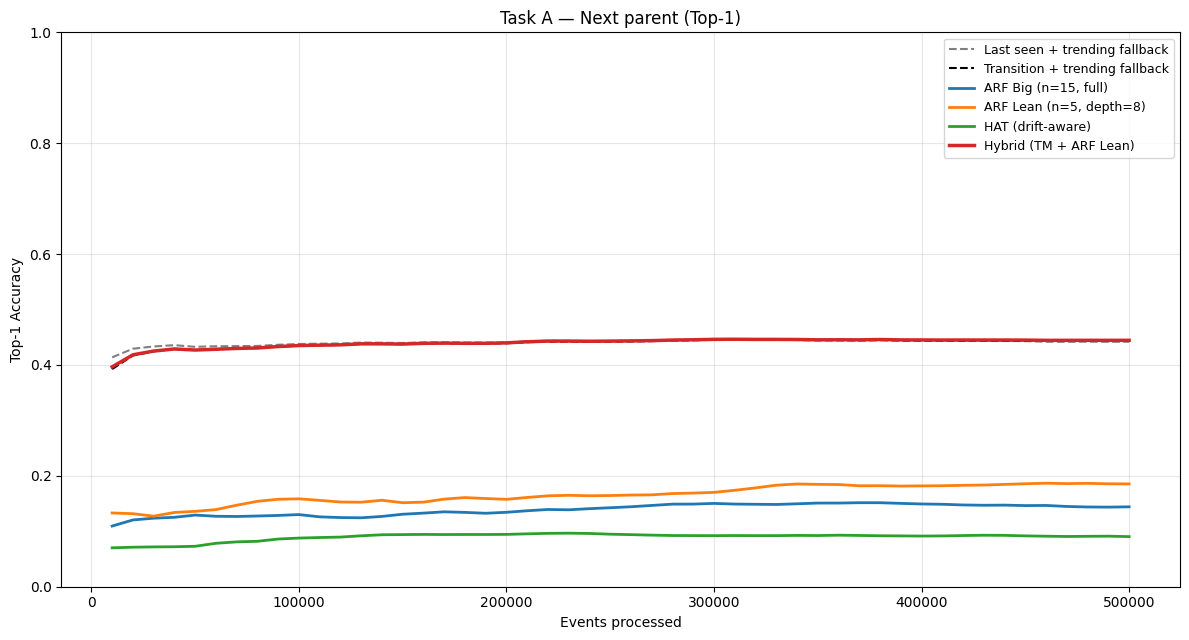

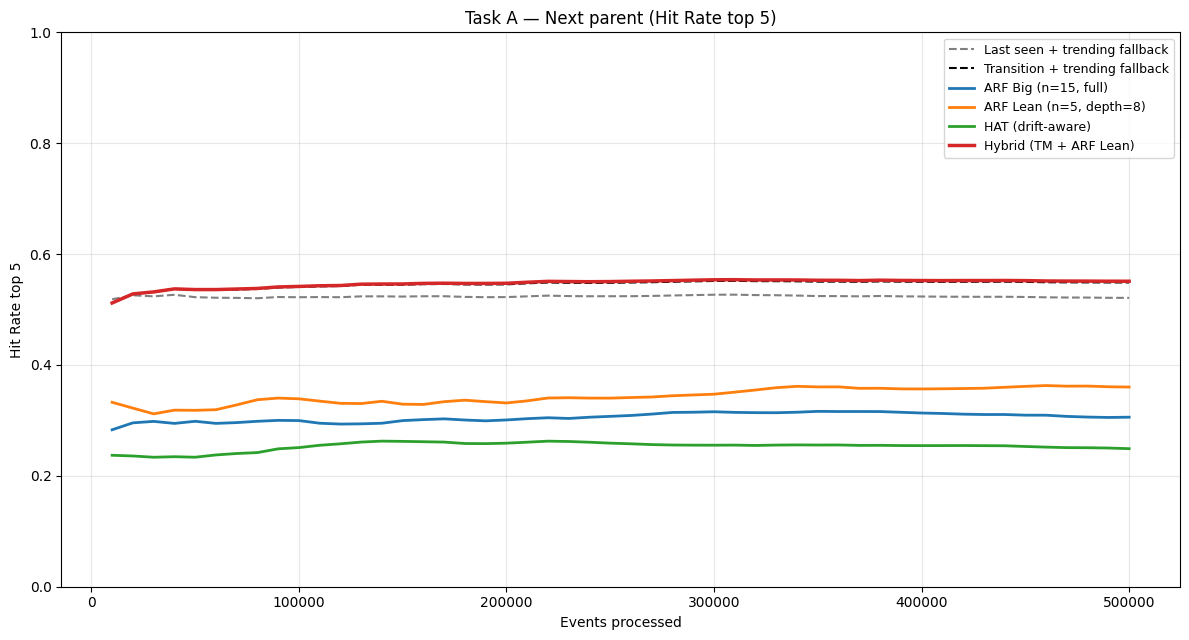

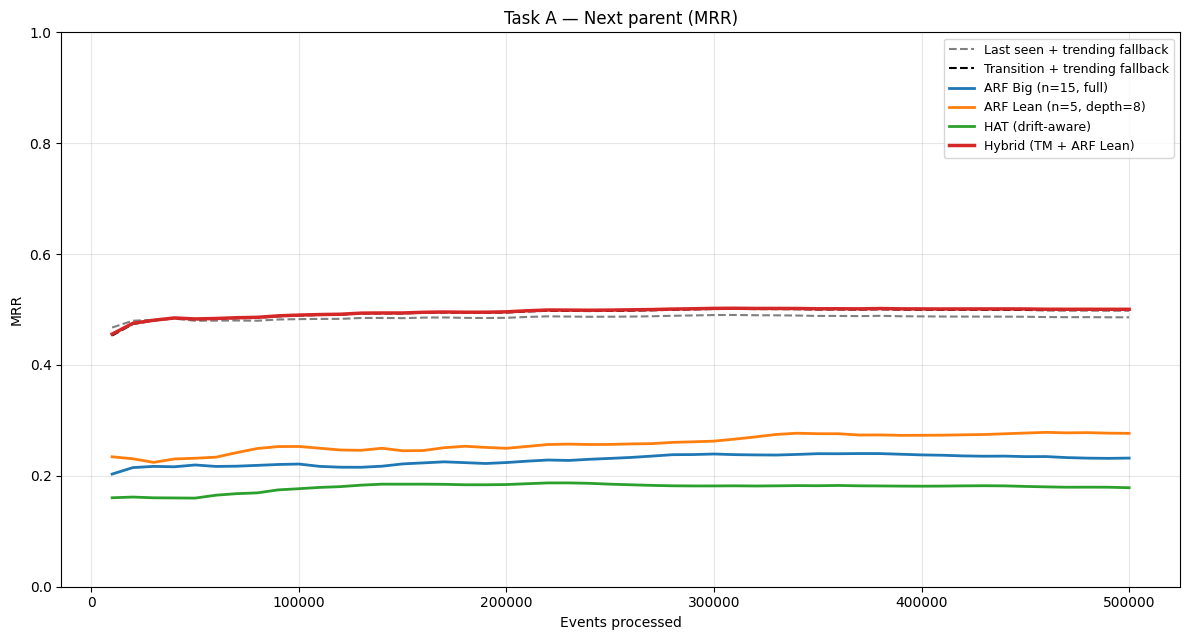

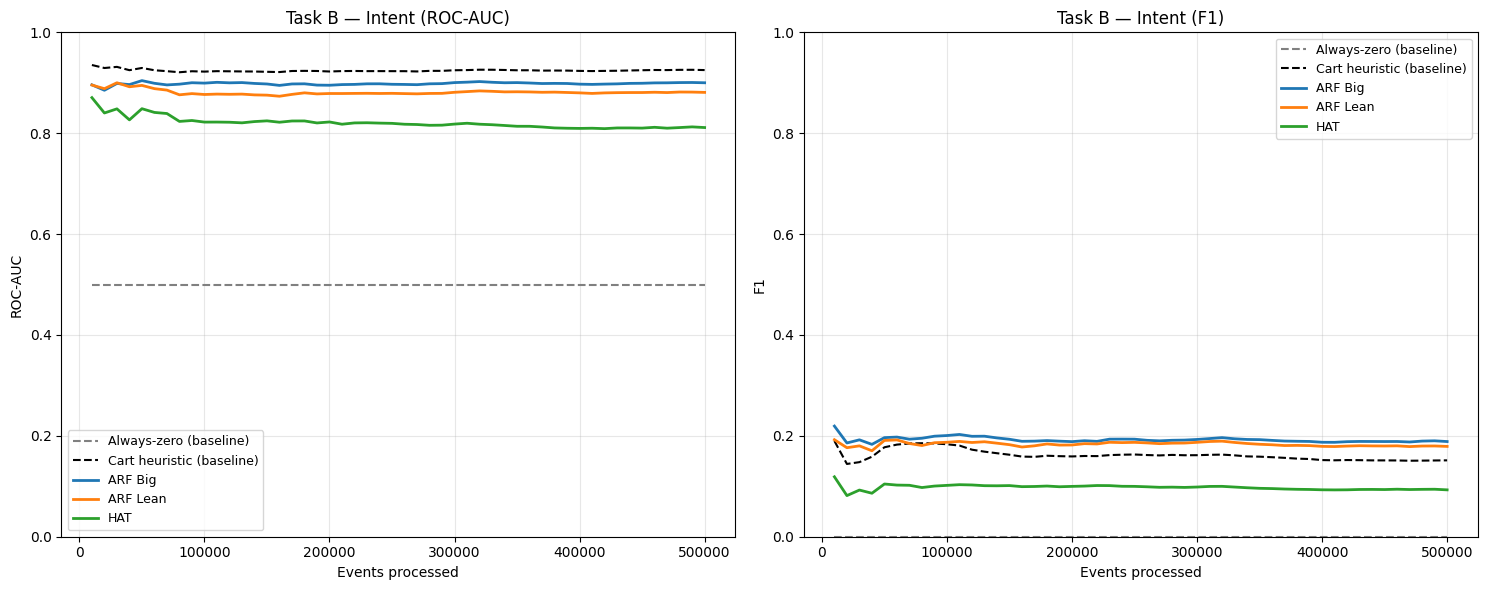

In [12]:
def style(ax, title, ylabel):
    ax.set_xlabel('Events processed')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='best', frameon=True, fontsize=9)
    ax.grid(True, alpha=0.3)

rows = history['rows']

MODEL_PLOT_STYLE = {
    'last_seen':  ('Last seen + trending fallback',  'gray',    '--', 1.5),
    'transition': ('Transition + trending fallback', 'black',   '--', 1.5),
    'arf_big':    ('ARF Big (n=15, full)',           '#1f77b4', '-',  2.0),
    'arf_lean':   ('ARF Lean (n=5, depth=8)',        '#ff7f0e', '-',  2.0),
    'hat':        ('HAT (drift-aware)',              '#2ca02c', '-',  2.0),
    'hybrid':     ('Hybrid (TM + ARF Lean)',         '#d62728', '-',  2.5),
}

INTENT_PLOT_STYLE = {
    'zero':     ('Always-zero (baseline)',     'gray',    '--', 1.5),
    'cart':     ('Cart heuristic (baseline)',  'black',   '--', 1.5),
    'arf_big':  ('ARF Big',                    '#1f77b4', '-',  2.0),
    'arf_lean': ('ARF Lean',                   '#ff7f0e', '-',  2.0),
    'hat':      ('HAT',                        '#2ca02c', '-',  2.0),
}

def plot_parent_metric(metric_key, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(12, 6.5))
    for mk, (label, color, ls, lw) in MODEL_PLOT_STYLE.items():
        ax.plot(rows, history[f'p_{mk}_{metric_key}'],
                label=label, color=color, linestyle=ls, linewidth=lw)
    style(ax, title, ylabel)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, filename), dpi=150)
    plt.show()

plot_parent_metric('top1', 'Top-1 Accuracy',
                   'Task A — Next parent (Top-1)', 'task_a_top1.png')
plot_parent_metric('top5', f'Hit Rate top {TOP_K}',
                   f'Task A — Next parent (Hit Rate top {TOP_K})', 'task_a_top5.png')
plot_parent_metric('mrr', 'MRR',
                   'Task A — Next parent (MRR)', 'task_a_mrr.png')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for ax, suffix, ylabel, title in [
    (ax1, 'roc', 'ROC-AUC', 'Task B — Intent (ROC-AUC)'),
    (ax2, 'f1',  'F1',      'Task B — Intent (F1)'),
]:
    for mk, (label, color, ls, lw) in INTENT_PLOT_STYLE.items():
        ax.plot(rows, history[f'i_{mk}_{suffix}'],
                label=label, color=color, linestyle=ls, linewidth=lw)
    style(ax, title, ylabel)
    ax.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'task_b_intent.png'), dpi=150)
plt.show()


 ## 10. Final results

In [13]:
print("=" * 80)
print("FINAL — TASK A: Next parent  (Top-1 | Top-5 | MRR)")
print("=" * 80)
for mk in PARENT_MODEL_KEYS:
    label = MODEL_PLOT_STYLE[mk][0]
    t1 = m_parent[mk]['top1'].get()
    t5 = m_parent[mk]['top5'].get()
    mr = m_parent[mk]['mrr'].get()
    print(f"  {label:<35} : {t1:.4f}  |  {t5:.4f}  |  {mr:.4f}")

print()
print("=" * 60)
print("FINAL — TASK B: Intent (ROC-AUC | F1) ")
print("=" * 60)
for mk in INTENT_MODEL_KEYS:
    label = INTENT_PLOT_STYLE[mk][0]
    roc = m_intent[mk]['roc'].get()
    f1  = m_intent[mk]['f1'].get()
    print(f"  {label:<35} : {roc:.4f}  |  {f1:.4f}")

print(f"\nPlots saved to: {PLOT_DIR}")


FINAL — TASK A: Next parent  (Top-1 | Top-5 | MRR)
  Last seen + trending fallback       : 0.4433  |  0.5210  |  0.4860
  Transition + trending fallback      : 0.4426  |  0.5488  |  0.4985
  ARF Big (n=15, full)                : 0.1441  |  0.3058  |  0.2320
  ARF Lean (n=5, depth=8)             : 0.1854  |  0.3602  |  0.2767
  HAT (drift-aware)                   : 0.0904  |  0.2490  |  0.1785
  Hybrid (TM + ARF Lean)              : 0.4445  |  0.5510  |  0.5004

FINAL — TASK B: Intent (ROC-AUC | F1) 
  Always-zero (baseline)              : 0.5000  |  0.0000
  Cart heuristic (baseline)           : 0.9252  |  0.1514
  ARF Big                             : 0.9000  |  0.1887
  ARF Lean                            : 0.8809  |  0.1790
  HAT                                 : 0.8112  |  0.0929

Plots saved to: /Users/maciej/Desktop/MLDS_workspace/data_retailrocket/plots_v10
